In [120]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import pandas as pd
PROJECT_PATH = "/content/drive/MyDrive/Ecommer_AI_Project"

order_items = pd.read_csv(f"{PROJECT_PATH}/data/raw/olist_order_items_dataset.csv")



In [122]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [123]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [124]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [125]:
order_items.duplicated().sum()

np.int64(0)

In [126]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

In [127]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [128]:
order_items[["price","freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


,0
price,"Axes(0.125,0.11;0.352273x0.77)"
freight_value,"Axes(0.547727,0.11;0.352273x0.77)"


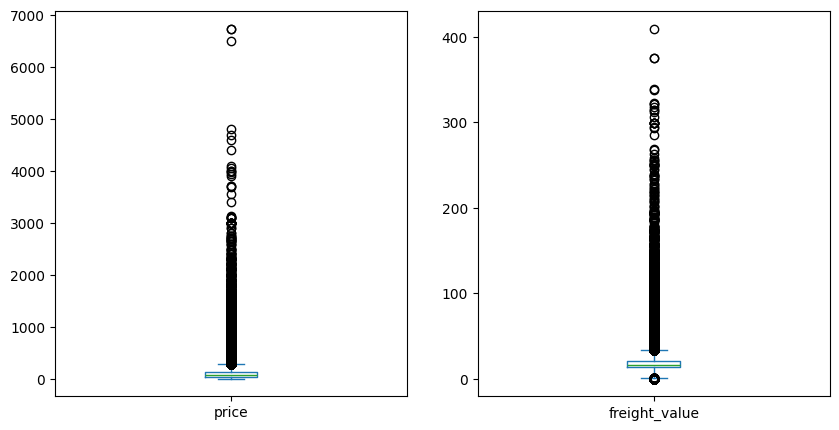

In [129]:
from re import sub
order_items[["price","freight_value"]].plot(
    kind = "box",
    subplots=True,
    figsize=(10, 5)
    )

In [130]:
Q1 = order_items["price"].quantile(0.25)
Q3 = order_items["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)


Q1: 39.9
Q3: 134.9
IQR: 95.0
Lower: -102.6
Upper: 277.4


In [131]:
outliers = order_items[(order_items["price"] < lower) | (order_items["price"] > upper)]
print("number of outiers :", outliers)

number of outiers :                                 order_id  order_item_id  \
7       000576fe39319847cbb9d288c5617fa6              1   
16      0009c9a17f916a706d71784483a5d643              1   
26      0011d82c4b53e22e84023405fb467e57              1   
30      00137e170939bba5a3134e2386413108              1   
39      0017afd5076e074a48f1f1a4c7bac9c5              1   
...                                  ...            ...   
112586  ffdc5e3279114c523a09296f8fd28331              1   
112592  ffde92ba447b33a47d1c04d203f10f41              1   
112632  fff7c4452f050315db1b3f24d9df5fcd              1   
112645  fffc94f6ce00a00581880bf54a75a037              1   
112646  fffcd46ef2263f404302a634eb57f7eb              1   

                              product_id                         seller_id  \
7       557d850972a7d6f792fd18ae1400d9b6  5996cddab893a4652a15592fb58ab8db   
16      3f27ac8e699df3d300ec4a5d8c5cf0b2  fcb5ace8bcc92f75707dc0f01a27d269   
26      c389f712c4b4510bc997cee93e8b1

In [132]:
Q1_f = order_items["freight_value"].quantile(0.25)
Q3_f = order_items["freight_value"].quantile(0.75)

IQR_f = Q3_f - Q1_f

lower_f = Q1_f - 1.5 * IQR_f
upper_f = Q3_f + 1.5 * IQR_f

print("Q1:", Q1_f)
print("Q3:", Q3_f)
print("IQR:", IQR_f)
print("Lower:", lower_f)
print("Upper:", upper_f)

Q1: 13.08
Q3: 21.15
IQR: 8.069999999999999
Lower: 0.9750000000000032
Upper: 33.254999999999995


In [133]:
freight_outliers = order_items[
    order_items["freight_value"] > upper_f
]

print("Number of freight outliers:", len(freight_outliers))

Number of freight outliers: 11613


In [134]:
freight_outliers[
    ["order_id", "product_id", "price", "freight_value"]
].sort_values(
    "freight_value",
    ascending=False).head(10)

,order_id,product_id,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,ec31d2a17b299511e7c8627be9337b9b,979.00,409.68
28044,3fde74c28a3d5d618c00f26d51baafa0,a3cd9517ebf5a50dca25acce54f3b171,2338.08,375.28
3303,076d1555fb53a89b0ef4d529e527a0f6,a3cd9517ebf5a50dca25acce54f3b171,2338.08,375.28
69797,9f49bd16053df810384e793386312674,256a9c364b75753b97bee410c9491ad8,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,97c948ebc8c04b26b7bbb095d4228f2a,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,97c948ebc8c04b26b7bbb095d4228f2a,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,46e24ce614899e36617e37ea1e4aa6ff,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,363a9f5b97bf194da23858be722a7aa5,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,7e53e051875b2a0c9f22acd8a9a29a20,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,363a9f5b97bf194da23858be722a7aa5,1045.00,314.40


In [135]:
order_items["total_price"] = order_items["price"] + order_items["freight_value"]

In [136]:
order_items[["price" ,"freight_value","total_price"]].head()

,price,freight_value,total_price
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


In [137]:
order_items["total_price"].describe()

,total_price
count,112650.000000
mean,140.644059
std,190.724394
min,6.080000
25%,55.220000
50%,92.320000
75%,157.937500
max,6929.310000


In [138]:
total_sales = order_items["total_price"].sum()
print("Total Sales:", total_sales)

Total Sales: 15843553.24


In [139]:
order_items[
    ["order_id", "product_id", "price", "freight_value", "total_price"]
].sort_values(
    "total_price",
    ascending=False
).head(10)


,order_id,product_id,price,freight_value,total_price
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00,194.31,6929.31
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00,193.21,6922.21
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00,227.66,6726.66
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00,151.34,4950.34
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00,74.34,4764.34
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00,91.78,4681.78
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87,113.45,4513.32
56663,80dfedb6d17bf23539beeef3c768f4d7,4ca7b91a31637bd24fb8e559d5e015e4,3999.00,195.76,4194.76
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99,75.27,4175.26
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00,104.51,4163.51


In [140]:
saller_sales = (order_items.groupby("seller_id")["total_price"].sum()).sort_values(ascending=False)
saller_sales.head(10)

,total_price
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
7c67e1448b00f6e969d365cea6b010ab,239536.44
53243585a1d6dc2643021fd1853d8905,235856.68
4a3ca9315b744ce9f8e9374361493884,235539.96
fa1c13f2614d7b5c4749cbc52fecda94,204084.73
da8622b14eb17ae2831f4ac5b9dab84a,185192.32
7e93a43ef30c4f03f38b393420bc753a,182754.05
1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
7a67c85e85bb2ce8582c35f2203ad736,162648.38


<Axes: title={'center': 'Top 10 Sellers by Total Sales'}, xlabel='seller_id'>

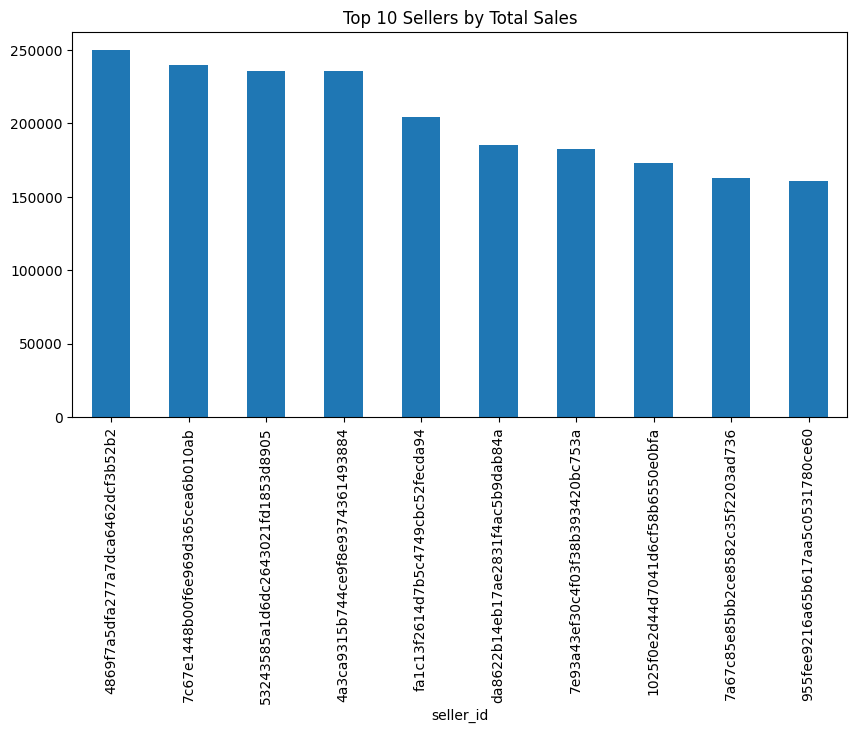

In [141]:
saller_sales.head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Sellers by Total Sales"
)


In [142]:
product_sales = (order_items.groupby("product_id")["total_price"].sum()).sort_values(ascending=False)
product_sales.head(10)

,total_price
product_id,
bb50f2e236e5eea0100680137654686c,67606.10
d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
6cdd53843498f92890544667809f1595,59093.99
99a4788cb24856965c36a24e339b6058,51071.60
d6160fb7873f184099d9bc95e30376af,50326.18
3dd2a17168ec895c781a9191c1e95ad7,48212.22
aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
5f504b3a1c75b73d6151be81eb05bdc9,41725.81
25c38557cf793876c5abdd5931f922db,40311.95


<Axes: title={'center': 'Top 10 Products by Total Sales'}, xlabel='product_id'>

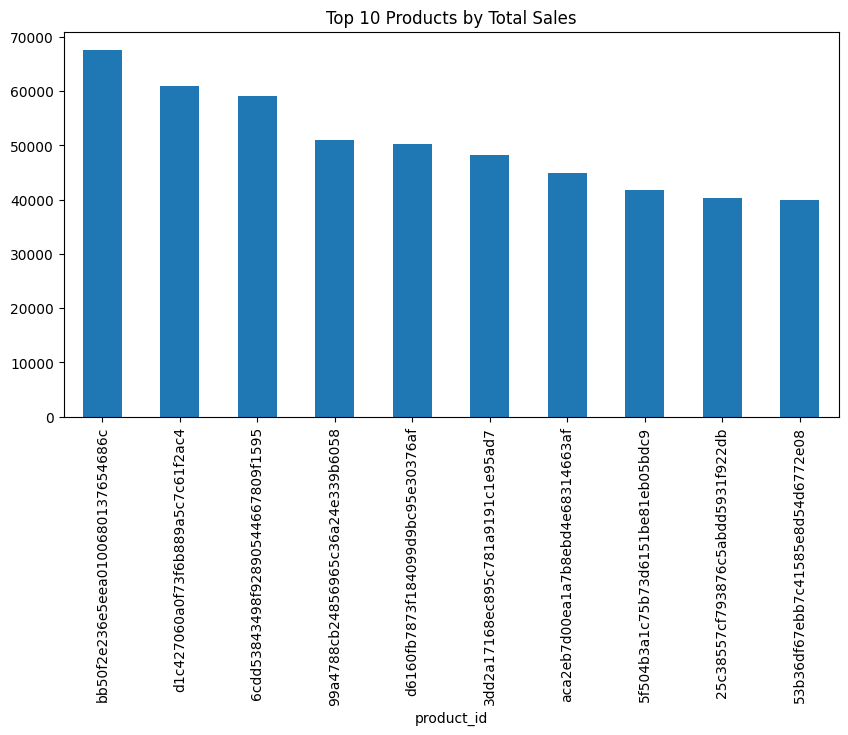

In [143]:
product_sales.head(10).plot(
    kind = "bar",
    figsize=(10,5),
    title="Top 10 Products by Total Sales"
)

In [144]:
products = pd.read_csv(f"{PROJECT_PATH}/data/raw/olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [145]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [146]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [147]:
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [148]:
order_items_products = order_items.merge(products, on="product_id",how ="left")
order_items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [149]:
order_items_products["product_category_name"].isnull().sum()

np.int64(1603)

In [150]:
order_items_products["product_category_name"] = (
    order_items_products["product_category_name"].fillna("Unknown")
)

In [151]:
order_items_products["product_category_name"].isnull().sum()

np.int64(0)

In [152]:
category_sales = (order_items_products.groupby("product_category_name")["total_price"].sum()
.sort_values(ascending=False))
category_sales.head(10)

,total_price
product_category_name,
beleza_saude,1441248.07
relogios_presentes,1305541.61
cama_mesa_banho,1241681.72
esporte_lazer,1156656.48
informatica_acessorios,1059272.40
moveis_decoracao,902511.79
utilidades_domesticas,778397.77
cool_stuff,719329.95
automotivo,685384.32


<Axes: title={'center': 'Top 10 Product Categories by Total Sales'}, xlabel='product_category_name'>

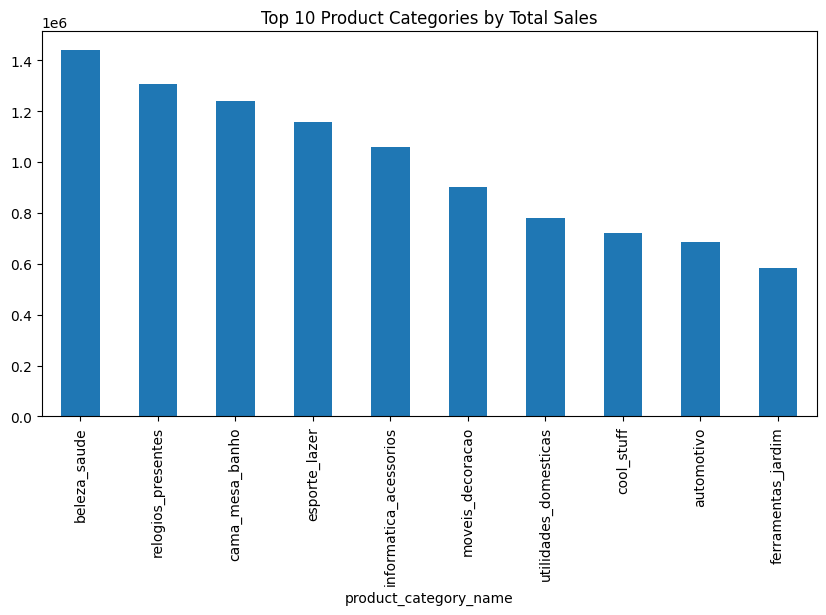

In [153]:
category_sales.head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Product Categories by Total Sales"
)

In [154]:
orders = pd.read_csv(
    f"{PROJECT_PATH}/data/raw/olist_orders_dataset.csv"

)

In [155]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [156]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [157]:
date_columns = ["order_purchase_timestamp",
                "order_approved_at",
                "order_delivered_carrier_date",
                "order_delivered_customer_date",
                "order_estimated_delivery_date" ]

for col in date_columns:
  orders[col] = pd.to_datetime(orders[col])

In [158]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [159]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [160]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [161]:
delivered_orders["delivery_day"] = (delivered_orders["order_delivered_customer_date"]
                                    - delivered_orders["order_purchase_timestamp"]).dt.days

In [162]:
delivered_orders["delivery_day"].describe()

,delivery_day
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


<Axes: title={'center': 'Distribution of Delivery Days'}, ylabel='Frequency'>

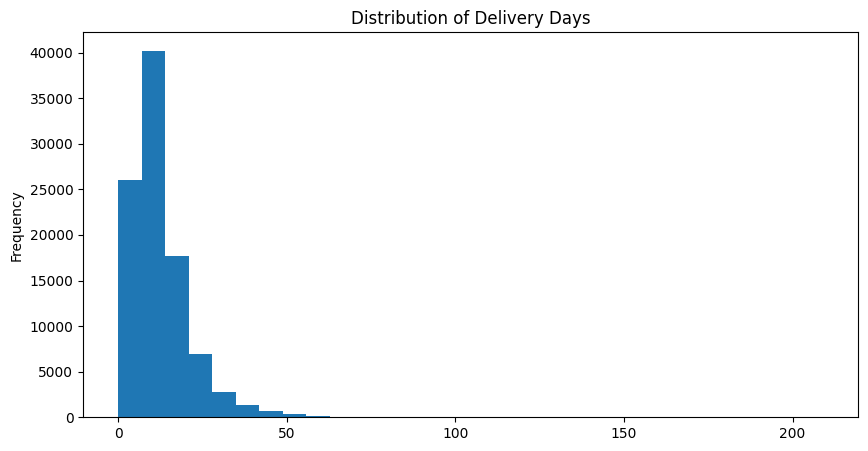

In [163]:
delivered_orders["delivery_day"].plot(
    kind="hist",
    bins=30,
    figsize=(10,5),
    title="Distribution of Delivery Days"
)

In [164]:
delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.days


In [165]:
late_orders = delivered_orders[delivered_orders["delay_days"] > 0]
len(late_orders)

6534

In [166]:
late_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_day,delay_days
count,6534,6534,6533,6534,6534,6534.000000,6534.000000
mean,2018-01-20 03:04:40.252984320,2018-01-20 15:20:26.471686656,2018-01-26 04:54:36.494872064,2018-02-23 01:53:05.309917184,2018-02-11 18:37:47.768595200,33.488062,10.620141
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,3.000000,1.000000
25%,2017-11-24 22:37:13.500000,2017-11-25 06:37:58.249999872,2017-11-29 23:47:12,2017-12-27 19:17:27,2017-12-19 00:00:00,24.000000,3.000000
50%,2018-02-19 16:49:57.500000,2018-02-20 07:16:03.500000,2018-02-23 19:57:33,2018-03-23 20:28:22,2018-03-15 00:00:00,31.000000,7.000000
75%,2018-03-22 13:46:18.249999872,2018-03-22 19:48:20.249999872,2018-03-27 21:12:38,2018-04-28 14:54:04.500000,2018-04-16 00:00:00,40.000000,13.000000
max,2018-08-24 18:26:00,2018-08-24 22:05:08,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-08-29 00:00:00,209.000000,188.000000
std,NaN,NaN,NaN,NaN,NaN,17.482556,14.644955


<Axes: title={'center': 'Distribution of Delivery Days'}, ylabel='Frequency'>

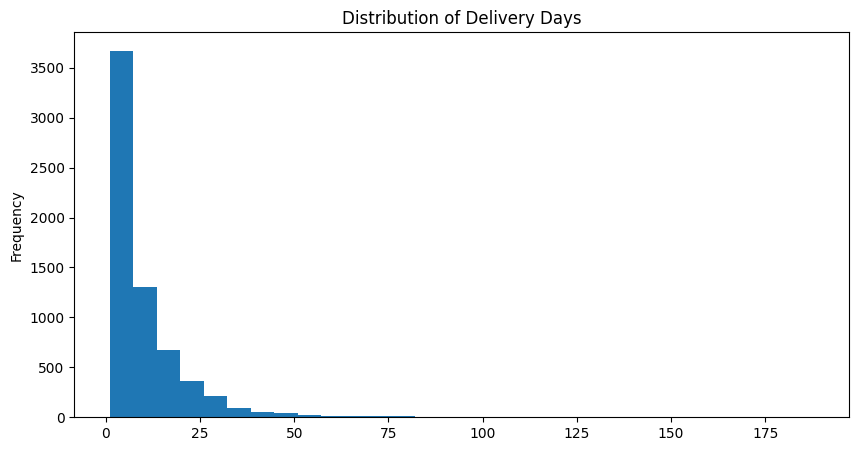

In [167]:
late_orders["delay_days"].plot(
    kind="hist",
    bins=30,
    figsize=(10,5),
    title="Distribution of Delivery Days"
)

In [168]:
late_orders["delay_days"].value_counts().sort_index().head(10)


,count
delay_days,
1.0,825
2.0,545
3.0,500
4.0,453
5.0,447
6.0,419
7.0,483
8.0,336
9.0,227


In [169]:
orders["purchese_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

monthly_orders = orders["purchese_month"].value_counts().sort_index()
monthly_orders

,count
purchese_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


<Axes: title={'center': 'Monthly Orders'}, xlabel='purchese_month'>

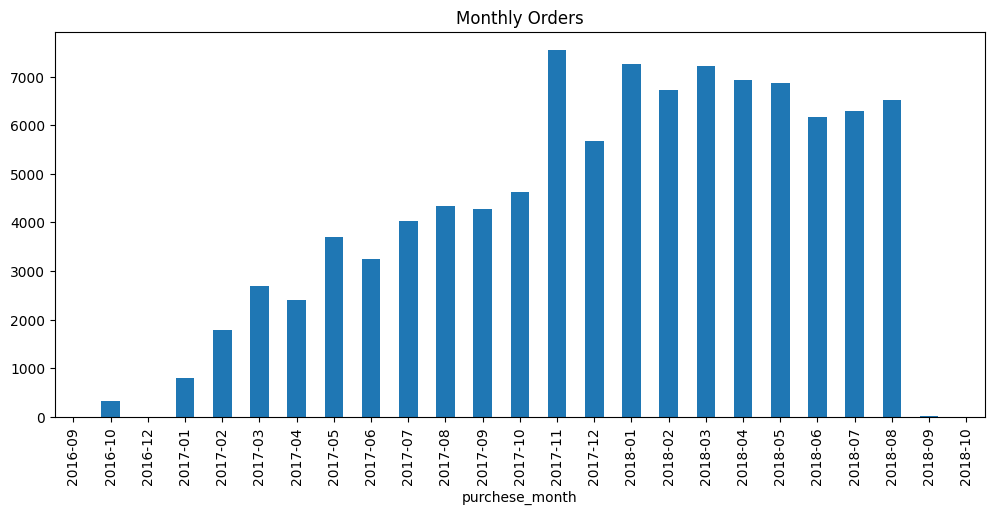

In [170]:
monthly_orders.plot(
    kind="bar",
    figsize=(12,5),
    title="Monthly Orders"
)

In [171]:
sales_data = order_items_products.merge(
    orders[["order_id","order_purchase_timestamp"]],
    on="order_id",
    how="left"

)

In [172]:
sales_data["purchase_month"] = (
    sales_data["order_purchase_timestamp"].dt.to_period("M")
    )

In [173]:
sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_purchase_timestamp,purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,2017-09-13 08:59:02,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,2017-04-26 10:53:06,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,2018-01-14 14:33:31,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,2018-08-08 10:00:35,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,2017-02-04 13:57:51,2017-02


In [174]:
monthly_sales = (
    sales_data
    .groupby("purchase_month")["total_price"]
    .sum()
    .sort_index()
)

monthly_sales

,total_price
purchase_month,
2016-09,354.75
2016-10,56808.84
2016-12,19.62
2017-01,137188.49
2017-02,286280.62
2017-03,432048.59
2017-04,412422.24
2017-05,586190.95
2017-06,502963.04


<Axes: title={'center': 'Monthly Sales trend'}, xlabel='purchase_month'>

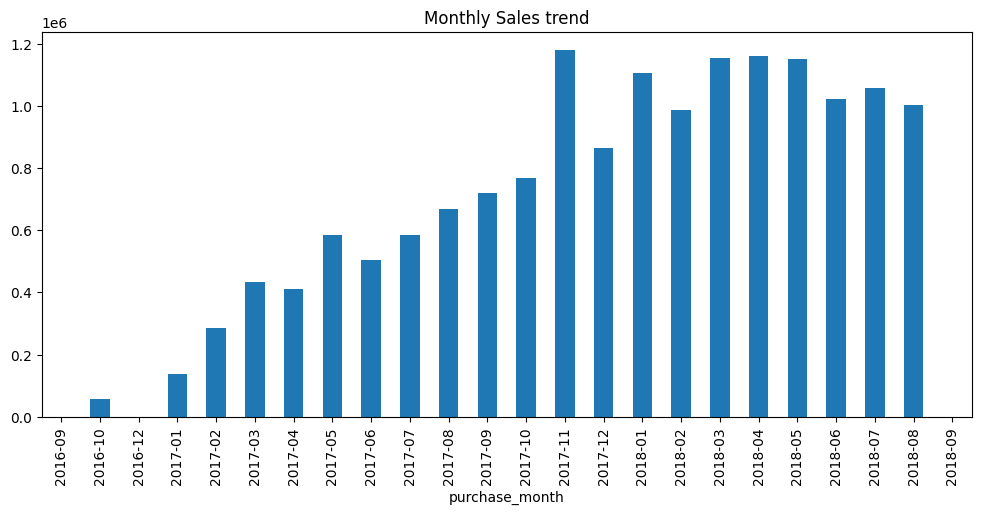

In [175]:
monthly_sales.plot(
    kind="bar",
    figsize=(12,5),
    title="Monthly Sales trend"
)

In [176]:
customers = pd.read_csv(
    f"{PROJECT_PATH}/data/raw/olist_customers_dataset.csv"
)
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [177]:
state_customers = (
    customers["customer_state"].value_counts()

)
state_customers.head()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045


In [178]:
orders_customers = orders.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id",
    how="left"
)

In [179]:
orders_customers.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [180]:
sales_customer = sales_data.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

In [181]:
sales_customer = sales_customer.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)


In [182]:
state_sales = (
    sales_customer
    .groupby("customer_state")["total_price"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)

,total_price
customer_state,
SP,5921678.12
RJ,2129681.98
MG,1856161.49
RS,885826.76
PR,800935.44
BA,611506.67
SC,610213.60
DF,353229.44
GO,347706.93


In [183]:
customer_orders = (
    orders_customers
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

customer_orders.value_counts().sort_index()


,count
order_id,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


In [184]:
repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.count()
repeat_percentage = (
    repeat_customers / total_customers * 100
)


print("Percentage of repeat customers:", repeat_percentage)


Percentage of repeat customers: 3.1187562437562435


In [185]:
customer_sales = sales_customer.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [186]:
top_customers = (
    customer_sales
    .groupby("customer_unique_id")["total_price"]
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

,total_price
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,13664.08
da122df9eeddfedc1dc1f5349a1a690c,7571.63
763c8b1c9c68a0229c42c9fc6f662b93,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31
459bef486812aa25204be022145caa62,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4007669dec559734d6f53e029e360987,6081.54
5d0a2980b292d049061542014e8960bf,4809.44
eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


In [187]:
customer_avg_spending = top_customers.mean()

customer_avg_spending

np.float64(166.04017229092435)

In [188]:
top_customers.describe()

,total_price
count,95420.000000
mean,166.040172
std,228.320333
min,9.590000
25%,63.100000
50%,107.940000
75%,183.220000
max,13664.080000


In [189]:
customer_segments = pd.cut(
    top_customers,
    bins=[0, 100, 500, float("inf")],
    labels=["Low", "Medium", "High"]
)

customer_segments.value_counts()

,count
total_price,
Medium,46869
Low,44127
High,4424


In [190]:
orders[['order_id', 'customer_id']].head()

,order_id,customer_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c


In [191]:
customer_orders = order_items.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

customer_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,customer_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795


In [192]:
customer_spending = customer_orders.groupby('customer_id')['total_price'].sum().reset_index()

customer_spending.head()

,customer_id,total_price
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


In [193]:
top_customers = customer_spending.sort_values(
    by='total_price',
    ascending=False
).head(10)

top_customers


,customer_id,total_price
8475,1617b1357756262bfa56ab541c47bc16,13664.08
91284,ec5b2ba62e574342386871631fafd3fc,7274.88
76948,c6e2731c5b391845f6800c97401a43a9,6929.31
94398,f48d464a0baaea338cb25f816991ab1f,6922.21
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66
2049,05455dfa7cd02f13d132aa7a6a9729c6,6081.54
86248,df55c14d1476a9a3467f131269c2477f,4950.34
86733,e0a2412720e9ea4f26c1ac985f6a7358,4809.44
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34
23771,3d979689f636322c62418b6346b1c6d2,4681.78


In [194]:
customer_spending['spending_segment'] = pd.qcut(
    customer_spending['total_price'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

customer_spending['spending_segment'].value_counts()

,count
spending_segment,
Medium,32891
Low,32889
High,32886


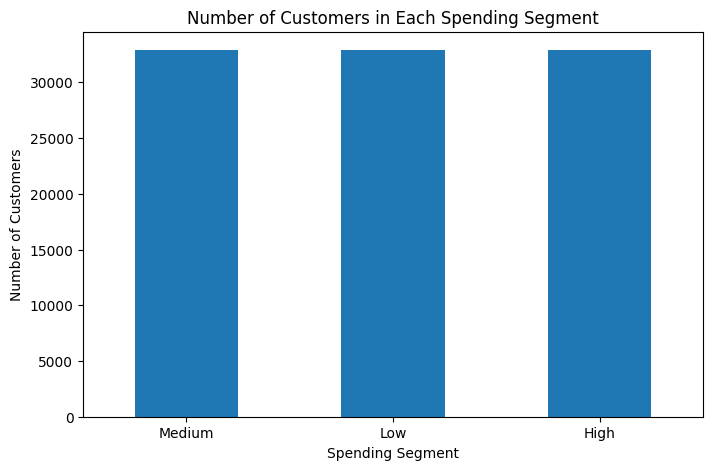

In [195]:
import matplotlib.pyplot as plt
customer_spending['spending_segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)
plt.xlabel('Spending Segment')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Spending Segment')
plt.xticks(rotation=0)
plt.show()

In [196]:
customer_spending.groupby('spending_segment')['total_price'].agg(
    ['count', 'mean', 'min', 'max']
)

/tmp/ipykernel_1104/1876365905.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_spending.groupby('spending_segment')['total_price'].agg(


,count,mean,min,max
spending_segment,,,,
Low,32889,49.110281,9.59,73.50
Medium,32891,106.921849,73.51,147.55
High,32886,325.719111,147.56,13664.08


In [197]:
customer_orders_count = customer_orders.groupby('customer_id')['order_id'].nunique().reset_index()

customer_orders_count.columns = ['customer_id', 'order_count']

customer_orders_count.sort_values(
    by='order_count',
    ascending=False
).head(10)

,customer_id,order_count
98665,ffffa3172527f765de70084a7e53aae8,1
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1
5,0004164d20a9e969af783496f3408652,1
6,000419c5494106c306a97b5635748086,1
7,00046a560d407e99b969756e0b10f282,1
8,00050bf6e01e69d5c0fd612f1bcfb69c,1


In [198]:
customers[['customer_id', 'customer_unique_id']].head()

,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


In [199]:
orders_customer = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

orders_customer.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchese_month,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6


In [200]:
customer_order_count = orders_customer.groupby(
    'customer_unique_id'
)['order_id'].nunique().reset_index()

customer_order_count.columns = [
    'customer_unique_id',
    'order_count'
]

customer_order_count.sort_values(
    by='order_count',
    ascending=False
).head(10)

,customer_unique_id,order_count
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
76082,ca77025e7201e3b30c44b472ff346268,7
82883,dc813062e0fc23409cd255f7f53c7074,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
83540,de34b16117594161a6a89c50b289d35a,6
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6


In [201]:
orders_customer = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

orders_customer.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchese_month,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6


In [202]:
customer_order_count = orders_customer.groupby(
    'customer_unique_id'
)['order_id'].nunique().reset_index()

customer_order_count.columns = [
    'customer_unique_id',
    'order_count'
]

customer_order_count.sort_values(
    by='order_count',
    ascending=False
).head(10)

,customer_unique_id,order_count
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
76082,ca77025e7201e3b30c44b472ff346268,7
82883,dc813062e0fc23409cd255f7f53c7074,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
83540,de34b16117594161a6a89c50b289d35a,6
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6


In [203]:
customer_type = customer_order_count.copy()
customer_type['customer_type'] = customer_type['order_count'].apply(
    lambda x: 'One' if x  == 1 else 'Repeat'
)




customer_type['customer_type'].value_counts()

,count
customer_type,
One,93099
Repeat,2997


In [204]:
customer_orders = order_items.merge(
    orders_customer[['order_id', 'customer_unique_id']],
    on='order_id',
    how='left'
)

customer_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,customer_unique_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,871766c5855e863f6eccc05f988b23cb
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,eb28e67c4c0b83846050ddfb8a35d051
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,3818d81c6709e39d06b2738a8d3a2474
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,af861d436cfc08b2c2ddefd0ba074622
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,64b576fb70d441e8f1b2d7d446e483c5


In [205]:
customer_spending = customer_orders.groupby(
    'customer_unique_id'
)['total_price'].sum().reset_index()

customer_spending.head()

,customer_unique_id,total_price
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [206]:
customer_analysis = customer_spending.merge(
    customer_type,
    on='customer_unique_id',
    how='left'
)

customer_analysis.head()

,customer_unique_id,total_price,order_count,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,One
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,One
2,0000f46a3911fa3c0805444483337064,86.22,1,One
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,One
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,One


In [207]:
customer_analysis.groupby('customer_type')['total_price'].agg(
    ['count', 'mean', 'sum']
)

,count,mean,sum
customer_type,,,
One,92431,161.434051,14921510.75
Repeat,2989,308.478585,922042.49


In [208]:
monthly_sales = customer_orders.merge(
    orders[['order_id', 'purchese_month']],
    on='order_id',
    how='left'
)

monthly_sales = monthly_sales.groupby(
    'purchese_month'
)['total_price'].sum().reset_index()

monthly_sales.head()

,purchese_month,total_price
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


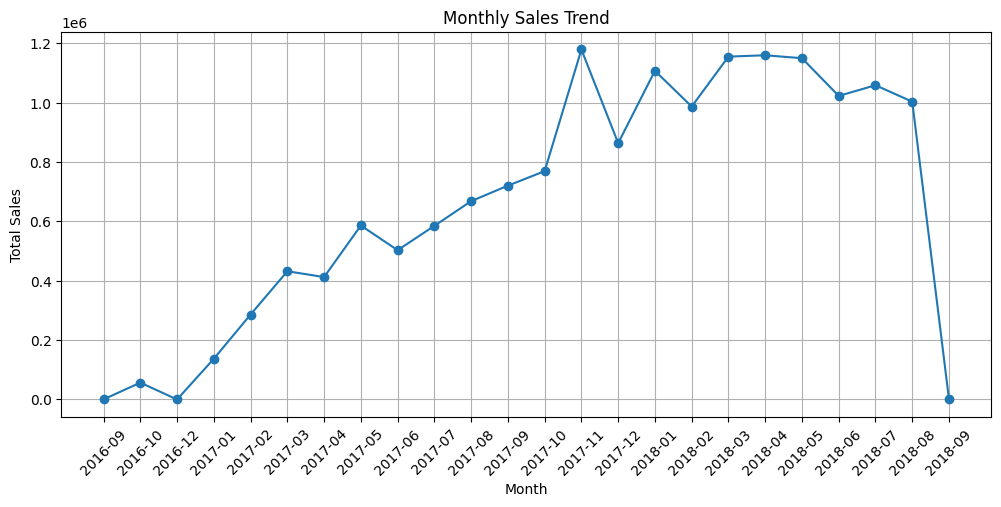

In [209]:
monthly_sales['purchese_month'] = monthly_sales['purchese_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['purchese_month'],
    monthly_sales['total_price'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [210]:
top_products = order_items.groupby('product_id')['total_price'].sum().reset_index()

top_products = top_products.sort_values(
    by='total_price',
    ascending=False
).head(10)

top_products

,product_id,total_price
24086,bb50f2e236e5eea0100680137654686c,67606.10
27039,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
14068,6cdd53843498f92890544667809f1595,59093.99
19742,99a4788cb24856965c36a24e339b6058,51071.60
27613,d6160fb7873f184099d9bc95e30376af,50326.18
8051,3dd2a17168ec895c781a9191c1e95ad7,48212.22
22112,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
12351,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
4996,25c38557cf793876c5abdd5931f922db,40311.95
10867,53b36df67ebb7c41585e8d54d6772e08,39957.93


In [211]:
products[['product_id','product_category_name']].head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


In [212]:
top_products_details = top_products.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

top_products_details

,product_id,total_price,product_category_name
0,bb50f2e236e5eea0100680137654686c,67606.10,beleza_saude
1,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03,informatica_acessorios
2,6cdd53843498f92890544667809f1595,59093.99,beleza_saude
3,99a4788cb24856965c36a24e339b6058,51071.60,cama_mesa_banho
4,d6160fb7873f184099d9bc95e30376af,50326.18,pcs
5,3dd2a17168ec895c781a9191c1e95ad7,48212.22,informatica_acessorios
6,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76,moveis_decoracao
7,5f504b3a1c75b73d6151be81eb05bdc9,41725.81,cool_stuff
8,25c38557cf793876c5abdd5931f922db,40311.95,bebes
9,53b36df67ebb7c41585e8d54d6772e08,39957.93,relogios_presentes


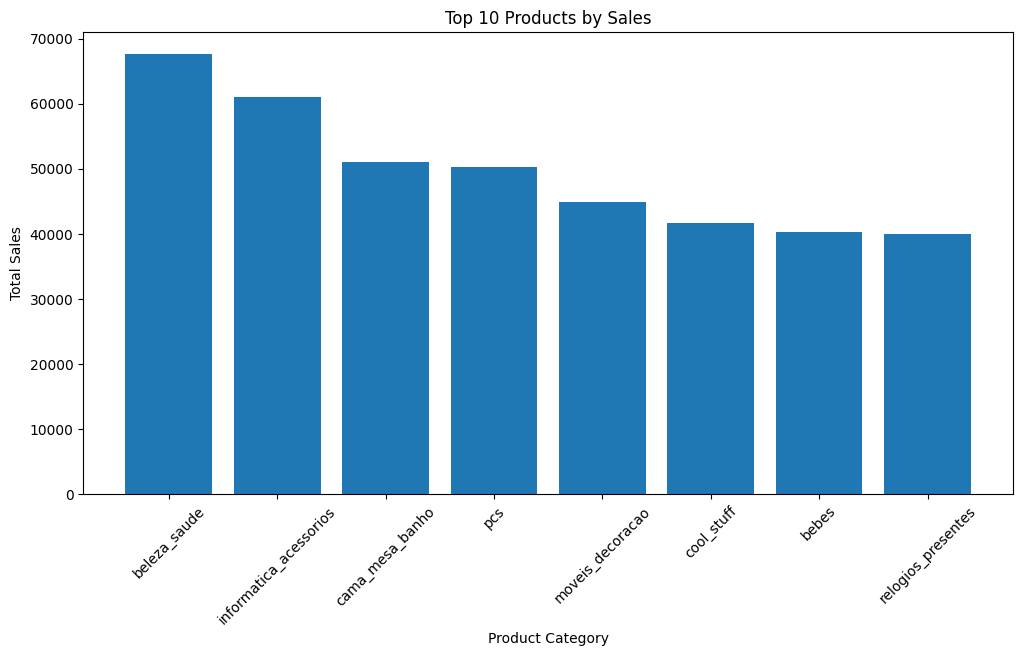

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    top_products_details['product_category_name'],
    top_products_details['total_price']
)
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [214]:
category_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

category_sales = category_sales.groupby(
    'product_category_name'
)['total_price'].sum().reset_index()

category_sales = category_sales.sort_values(
    by='total_price',
    ascending=False
)

category_sales.head(10)

,product_category_name,total_price
11,beleza_saude,1441248.07
66,relogios_presentes,1305541.61
13,cama_mesa_banho,1241681.72
32,esporte_lazer,1156656.48
44,informatica_acessorios,1059272.40
54,moveis_decoracao,902511.79
72,utilidades_domesticas,778397.77
26,cool_stuff,719329.95
8,automotivo,685384.32
40,ferramentas_jardim,584219.21


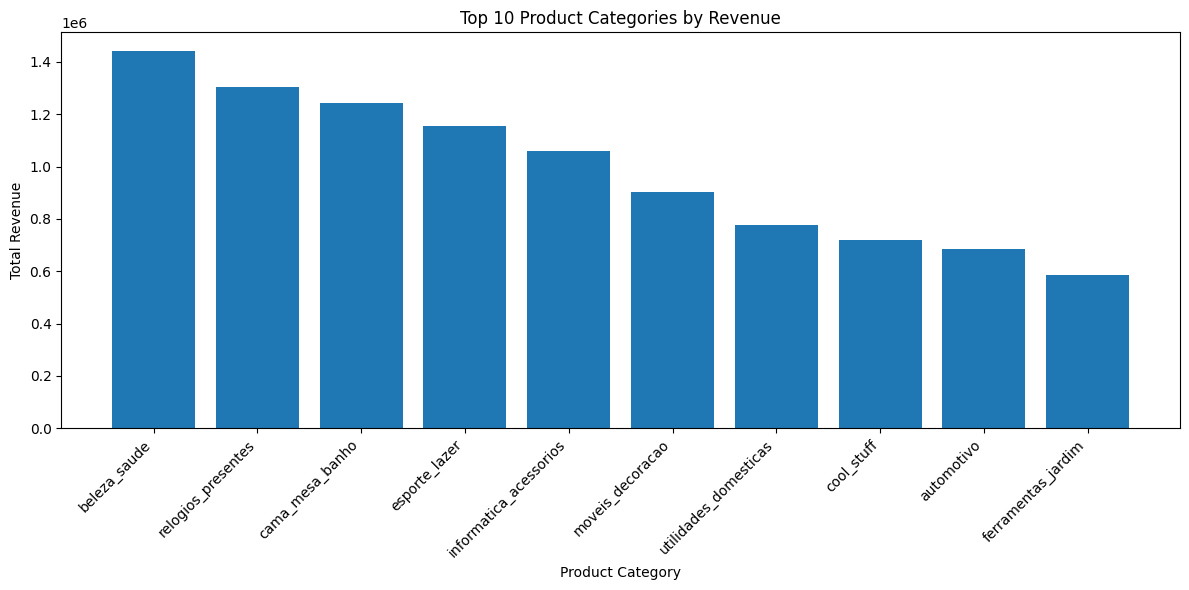

In [215]:
import matplotlib.pyplot as plt

top_categories = category_sales.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories['product_category_name'],
    top_categories['total_price']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [216]:
#saller analysis

top_sellers = order_items.groupby('seller_id')['total_price'].sum().reset_index()

top_sellers = top_sellers.sort_values(
    by='total_price',
    ascending=False
).head(10)

top_sellers

,seller_id,total_price
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44
1013,53243585a1d6dc2643021fd1853d8905,235856.68
881,4a3ca9315b744ce9f8e9374361493884,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38
1824,955fee9216a65b617aa5c0531780ce60,160602.68


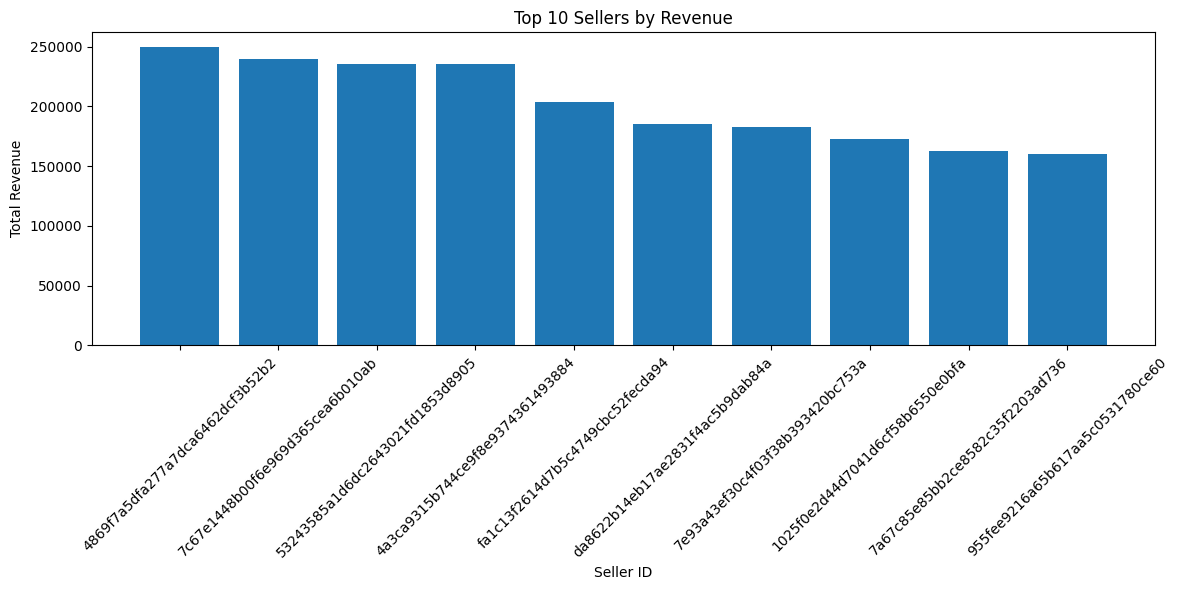

In [217]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(
    top_sellers['seller_id'],
    top_sellers['total_price']
)
plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [218]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchese_month'],
      dtype='object')

In [219]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_days'].describe()

,delivery_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [220]:
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['delay'].describe()

,delay
count,96476.000000
mean,-11.876881
std,10.183854
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [221]:
orders['delivery_status'] = orders['delay'].apply(
    lambda x: 'On Time' if x == 0
    else 'Late' if  x > 0
    else  'Early'
)

orders['delivery_status'].value_counts()


,count
delivery_status,
Early,91614
Late,6535
On Time,1292


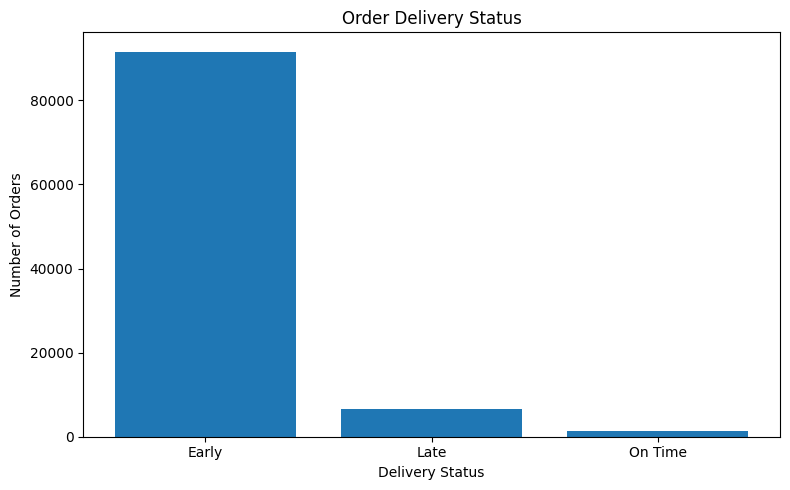

In [222]:
import matplotlib.pyplot as plt

status_counts = orders['delivery_status'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title('Order Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [223]:
late_category = orders[orders['delivery_status'] == 'Late'].merge(
    order_items[['order_id', 'product_id']],
    on='order_id',
    how='left'
)

late_category = late_category.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

In [224]:
late_category_counts = late_category[
    'product_category_name'
].value_counts().reset_index()

late_category_counts.columns = [
    'product_category_name',
    'late_orders'
]

late_category_counts.head(10)

,product_category_name,late_orders
0,cama_mesa_banho,770
1,beleza_saude,717
2,moveis_decoracao,574
3,esporte_lazer,532
4,informatica_acessorios,496
5,relogios_presentes,422
6,utilidades_domesticas,340
7,telefonia,308
8,automotivo,291
9,ferramentas_jardim,280


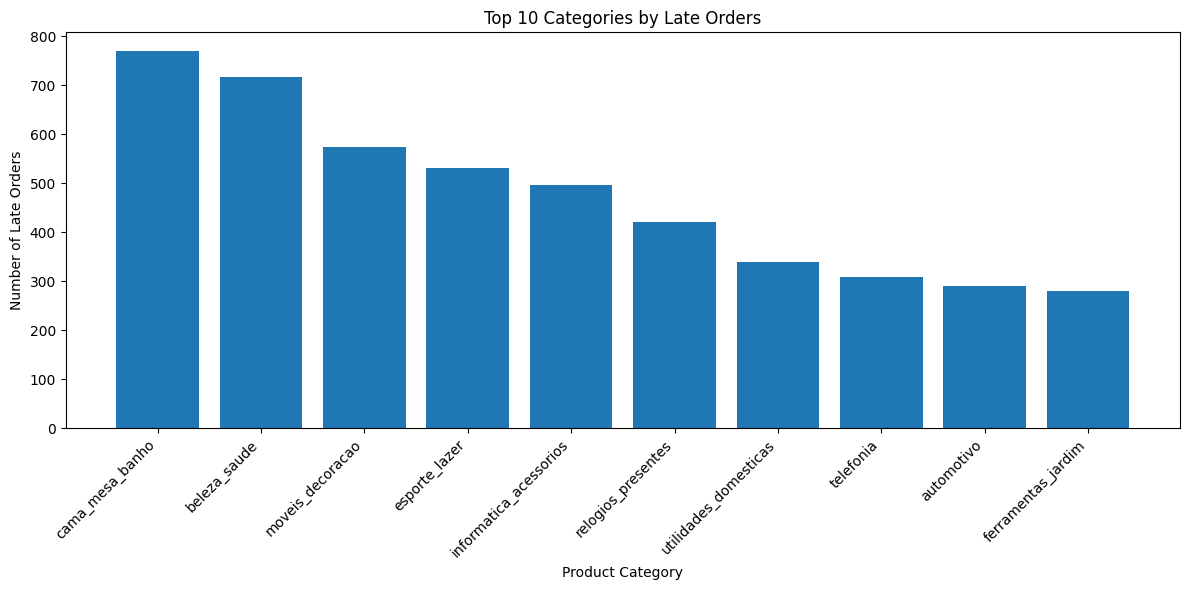

In [225]:
import matplotlib.pyplot as plt

top_late_categories = late_category_counts.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_late_categories['product_category_name'],
    top_late_categories['late_orders']
)

plt.title('Top 10 Categories by Late Orders')
plt.xlabel('Product Category')
plt.ylabel('Number of Late Orders')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [226]:
#order status
order_status_counts = orders['order_status'].value_counts()

order_status_counts


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


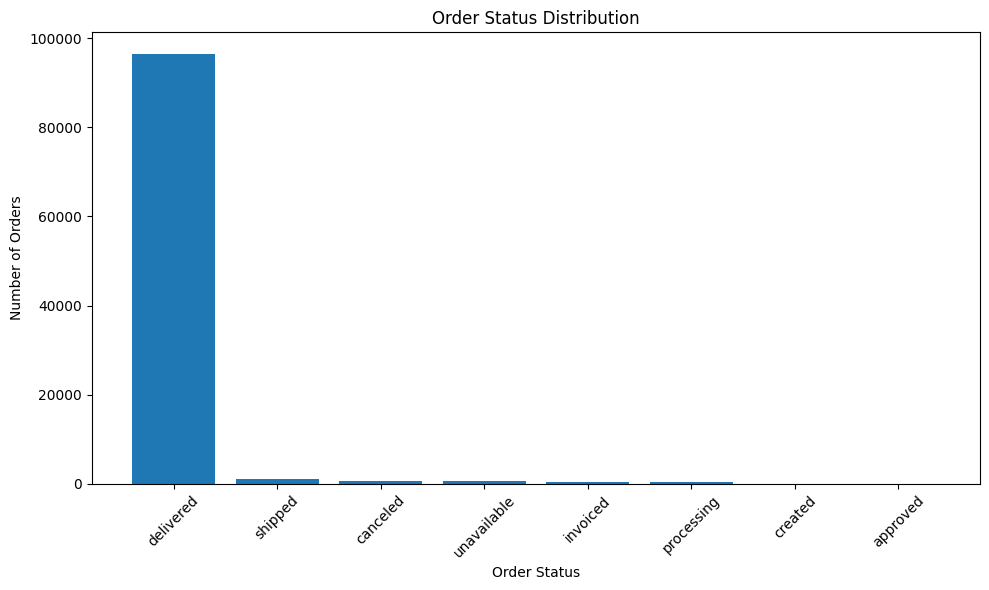

In [227]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    order_status_counts.index,
    order_status_counts.values
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [228]:
repeat_avg = 308.478585
one_avg = 161.434051

repeat_avg / one_avg

1.910864424755097

In [229]:
customer_features = orders_customer.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique')).reset_index()
customer_features

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,1
96092,fffea47cd6d3cc0a88bd621562a9d061,1
96093,ffff371b4d645b6ecea244b27531430a,1
96094,ffff5962728ec6157033ef9805bacc48,1


In [230]:
customer_spending.columns

Index(['customer_unique_id', 'total_price'], dtype='object')

In [231]:
customer_features = customer_spending.merge(
    customer_features,
    on='customer_unique_id',
    how='left'
)

customer_features.head()

,customer_unique_id,total_price,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1
2,0000f46a3911fa3c0805444483337064,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,196.89,1


In [232]:
customer_features['average_order_value'] = (
    customer_features['total_price'] / customer_features['order_count']
)

customer_features.head()

,customer_unique_id,total_price,order_count,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


In [241]:
customer_delivery = orders_customer.groupby(
    'customer_unique_id'
)['delivery_days'].mean().reset_index()

customer_delivery.columns = [
    'customer_unique_id',
    'average_delivery_days'
]

customer_delivery.head()

,customer_unique_id,average_delivery_days
0,0000366f3b9a7992bf8c76cfdf3221e2,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3.0
2,0000f46a3911fa3c0805444483337064,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,20.0
4,0004aac84e0df4da2b147fca70cf8255,13.0


In [235]:
orders_customer = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)
orders_customer.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchese_month', 'delivery_days', 'delay', 'delivery_status',
       'customer_unique_id'],
      dtype='object')

In [236]:
customer_late = orders_customer.groupby(
    'customer_unique_id'
)['delivery_status'].apply(
    lambda x: (x == 'Late').sum()
).reset_index()

customer_late.columns = [
    'customer_unique_id',
    'late_order_count'
]

customer_late.head()

,customer_unique_id,late_order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0
2,0000f46a3911fa3c0805444483337064,0
3,0000f6ccb0745a6a4b88665a16c9f078,0
4,0004aac84e0df4da2b147fca70cf8255,0


In [237]:
customer_features = customer_features.merge(
    customer_delivery,
    on='customer_unique_id',
    how='left'
)


In [238]:
customer_features = customer_features.merge(
    customer_late,
    on='customer_unique_id',
    how='left'
)

In [239]:
customer_features.head()

,customer_unique_id,total_price,order_count,average_order_value,average_delivery_days,late_order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,6.0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,3.0,0
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,25.0,0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,20.0,0
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,13.0,0


In [240]:
customer_features['customer_type'] = customer_features[
    'order_count'
].apply(
    lambda x: 'Repeat' if x > 1 else 'One'
)
customer_features['customer_type'].value_counts()

,count
customer_type,
One,92431
Repeat,2989


In [242]:
x = customer_features[[
    'total_price', 'order_count', 'average_order_value',
    'average_delivery_days', 'late_order_count'
]]
y = customer_features['customer_type']


In [243]:
x.head()


,total_price,order_count,average_order_value,average_delivery_days,late_order_count
0,141.90,1,141.90,6.0,0
1,27.19,1,27.19,3.0,0
2,86.22,1,86.22,25.0,0
3,43.62,1,43.62,20.0,0
4,196.89,1,196.89,13.0,0


In [244]:
y.head()

,customer_type
0,One
1,One
2,One
3,One
4,One


In [247]:
median_delivery = x['average_delivery_days'].median()

x['average_delivery_days'] = x['average_delivery_days'].fillna(
    median_delivery
)

/tmp/ipykernel_1104/2846332425.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['average_delivery_days'] = x['average_delivery_days'].fillna(


In [246]:
x.isna().sum()

,0
total_price,0
order_count,0
average_order_value,0
average_delivery_days,2064
late_order_count,0


In [248]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:",x_train.shape)
print("Testing data:",x_test.shape)

Training data: (76336, 5)
Testing data: (19084, 5)


In [249]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(x_train,y_train)


LogisticRegression(max_iter=1000)

In [250]:
y_pred = model.predict(x_test)
y_pred[:10]

array(['One', 'One', 'One', 'One', 'Repeat', 'Repeat', 'One', 'One',
       'One', 'One'], dtype=object)

In [251]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [252]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         One       1.00      1.00      1.00     18486
      Repeat       1.00      1.00      1.00       598

    accuracy                           1.00     19084
   macro avg       1.00      1.00      1.00     19084
weighted avg       1.00      1.00      1.00     19084



In [253]:
X = customer_features[
    [
        'total_price',
        'average_order_value',
        'average_delivery_days',
        'late_order_count'
    ]
]

print(X.columns)
print(X.isna().sum())

Index(['total_price', 'average_order_value', 'average_delivery_days',
       'late_order_count'],
      dtype='object')
total_price                 0
average_order_value         0
average_delivery_days    2064
late_order_count            0
dtype: int64


In [258]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

         One       1.00      1.00      1.00     18486
      Repeat       1.00      1.00      1.00       598

    accuracy                           1.00     19084
   macro avg       1.00      1.00      1.00     19084
weighted avg       1.00      1.00      1.00     19084



In [255]:
print(X_train.shape)
print(X_test.shape)

print(X_train.isna().sum())
print(X_train.dtypes)

(76336, 4)
(19084, 4)
total_price                 0
average_order_value         0
average_delivery_days    1648
late_order_count            0
dtype: int64
total_price              float64
average_order_value      float64
average_delivery_days    float64
late_order_count           int64
dtype: object


In [256]:
median_delivery = X['average_delivery_days'].median()

X['average_delivery_days'] = X['average_delivery_days'].fillna(
    median_delivery
)

/tmp/ipykernel_1104/4216820196.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['average_delivery_days'] = X['average_delivery_days'].fillna(


In [257]:
X.isna().sum()


,0
total_price,0
average_order_value,0
average_delivery_days,0
late_order_count,0


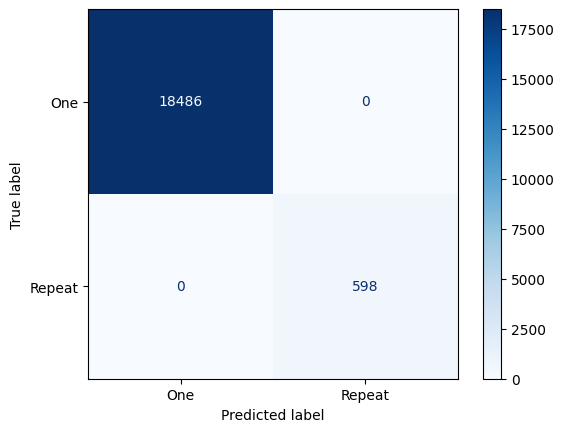

In [259]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [262]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient
0,total_price,0.679943
3,late_order_count,0.006255
2,average_delivery_days,-0.138360
1,average_order_value,-1.053541


In [266]:
Conclusion

The E-commerce Sales & Customer Intelligence project analyzed customer behavior,
sales, products, sellers, and delivery performance. EDA revealed important sales and
customer patterns, while machine learning was used to classify customers based on
their historical behavior. The analysis can help businesses identify valuable customers,
understand product/category performance, and improve delivery operations.


* Key Business Insights
Total Sales: ₹15.84M
Repeat Customers: 2,997
One-time Customers: 93,099
Average Delivery Time: 12.1 days
Late Orders: 6,535
Top Sales Category: beleza_saude
Most Late Orders: cama_mesa_banho

SyntaxError: invalid character '₹' (U+20B9) (2296285259.py, line 11)